<a href="https://colab.research.google.com/github/76ersGust/Aula-ia/blob/main/Fishmorph_Gustavo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Import kangle dataset**



In [ ]:
import kagglehub
import os
path = kagglehub.dataset_download("menegidio/fishmorph-dataset")
print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.
/kaggle/input/fishmorph-dataset
['FISHMORPH_Order_Dataset.csv', 'FISHMORPH_Family_Dataset.csv']


##**Importando o restante das bibliotecas**

In [ ]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#IMPORT MACHINE LEARNING
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


##**Análise dos dados padrão**

Nesta etapa verificamos o formato do dataset, os tipos de cada coluna, os valores nulos e as linhas duplicadas, e removemos os que forem encontrados.

In [ ]:
df = pd.read_csv(os.path.join(path, "FISHMORPH_Order_Dataset.csv"))
df.head()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cypriniformes
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Perciformes
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cypriniformes
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cypriniformes
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cypriniformes


In [ ]:
print("Formato:", df.shape)
print("\nTipos e não-nulos:")
df.info()

Formato: (8342, 11)

Tipos e não-nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Order   8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB


In [ ]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
print("\nLinhas duplicadas:", df.duplicated().sum())
df.describe().T

Valores nulos por coluna:
MBl      0
BEl      0
VEp      0
REs      0
OGp      0
RMl      0
BLs      0
PFv      0
PFs      0
CPt      0
Order    0
dtype: int64

Linhas duplicadas: 1


,count,mean,std,min,25%,50%,75%,max
MBl,8342.0,22.004517,33.612007,1.200000,7.000000,12.600000,24.500000,800.000000
BEl,8342.0,4.452438,2.338235,1.033084,3.139102,4.038851,5.002621,43.728161
VEp,8342.0,0.549087,0.094883,0.159248,0.487993,0.546213,0.605125,1.000000
REs,8342.0,0.391665,0.132814,0.000000,0.293205,0.389429,0.486221,1.026667
OGp,8342.0,0.381768,0.194352,0.000000,0.278014,0.406904,0.516001,1.026316
RMl,8342.0,0.399786,0.302658,0.000000,0.257999,0.361436,0.490671,7.060344
BLs,8342.0,0.571818,0.117486,0.224525,0.490052,0.564739,0.648039,1.230105
PFv,8342.0,0.285316,0.155629,0.000000,0.193134,0.275039,0.368876,0.857097
PFs,8342.0,0.189343,0.056109,0.000000,0.157972,0.183497,0.215031,0.511113
CPt,8342.0,2.560795,1.016659,0.000000,1.999744,2.436329,2.919818,15.452061


##**Distribuição das categorias**

Aqui contamos quantas amostras existem em cada ordem de peixe e mostramos em um gráfico de barras. Isso mostra se as classes estão balanceadas e quais têm poucos exemplos.

In [ ]:
TARGET = 'Order'

# Limpeza: remove nulos e duplicadas
antes = len(df)
df = df.dropna().drop_duplicates().reset_index(drop=True)
print(f"Linhas antes: {antes} | depois: {len(df)}")

# Features: só colunas numéricas (colunas de texto como Family/Genus/Species
features = [c for c in df.select_dtypes(include="number").columns if c != TARGET]
print("Features:", features)

Linhas antes: 8341 | depois: 8341
Features: ['MBl', 'BEl', 'VEp', 'REs', 'OGp', 'RMl', 'BLs', 'PFv', 'PFs', 'CPt']


Order
Cypriniformes         1933
Perciformes           1826
Siluriformes          1800
Characiformes         1281
Cyprinodontiformes     554
Osteoglossiformes      156
Clupeiformes           104
Gymnotiformes          101
Salmoniformes           92
Atheriniformes          71
Scorpaeniformes         70
Osmeriformes            69
Synbranchiformes        48
Beloniformes            33
Tetraodontiformes       31
Pleuronectiformes       28
Acipenseriformes        23
Mugiliformes            18
Syngnathiformes         16
Anguilliformes          16
Gasterosteiformes       13
Gonorynchiformes        10
Esociformes             10
Polypteriformes          9
Lepisosteiformes         6
Percopsiformes           6
Elopiformes              5
Batrachoidiformes        4
Gadiformes               3
Gobiesociformes          3
Amiiformes               1
Ophidiiformes            1
Name: count, dtype: int64


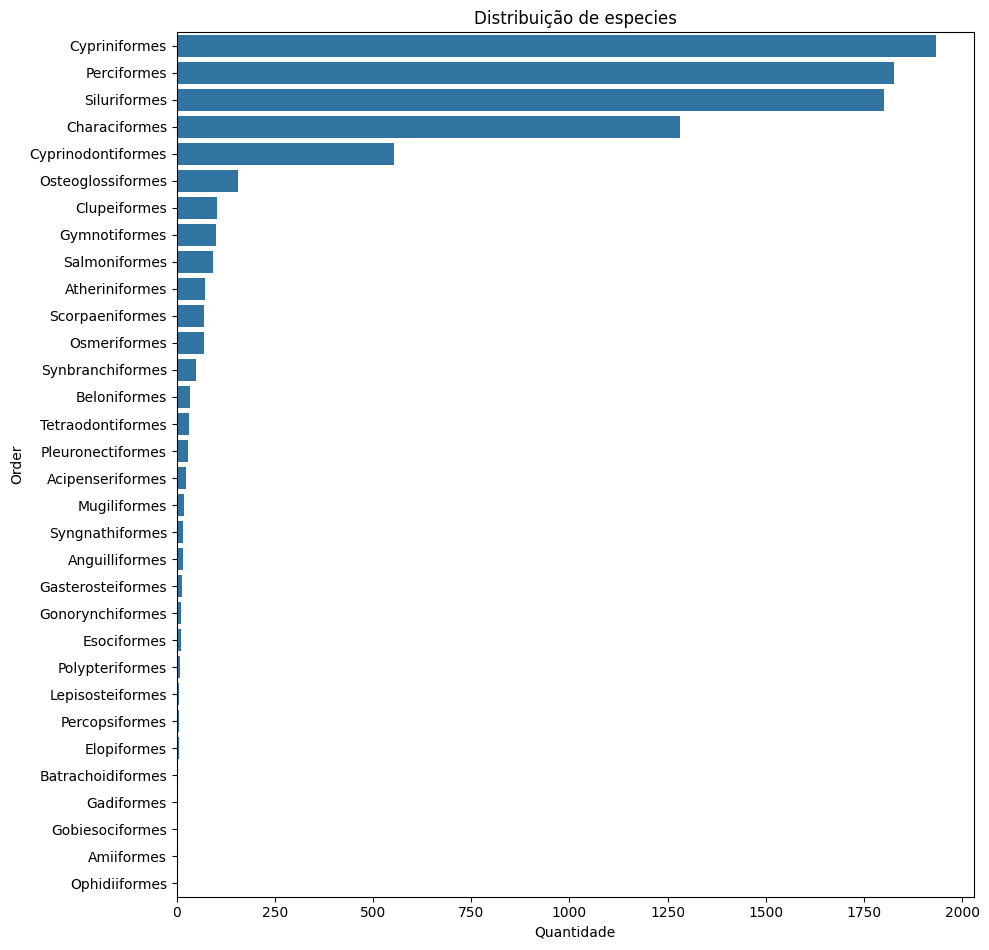

In [ ]:
contagem = df[TARGET].value_counts()
print(contagem)

fig, ax = plt.subplots(figsize=(10, max(4, 0.3*len(contagem))))
sns.countplot(y=TARGET, data=df, order=contagem.index, ax=ax)
ax.set_title(f"Distribuição de especies")
ax.set_xlabel("Quantidade"); plt.tight_layout(); plt.show()

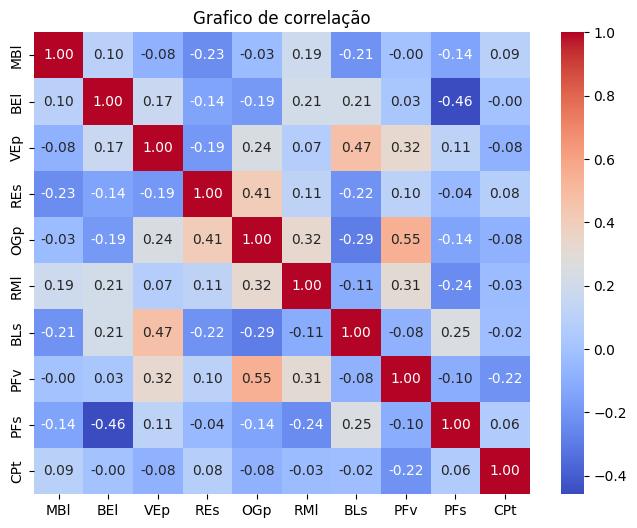

In [ ]:
# Visualização das features

plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Grafico de correlação"); plt.show()

##**Divisão treino e teste e validação cruzada**

Classes com poucas amostras impedem a divisão estratificada e o k-fold, então removo as com menos de **MIN_AMOSTRAS**. O **StandardScaler** entra dentro do **Pipeline** para ser ajustado só nos dados de treino de cada fold (sem vazamento).

In [ ]:
MIN_AMOSTRAS = 10
validas = contagem[contagem >= MIN_AMOSTRAS].index
descartadas = contagem[contagem < MIN_AMOSTRAS]
print("Classes descartadas (poucas amostras):", dict(descartadas))
d = df[df[TARGET].isin(validas)]

X = d[features]
le = LabelEncoder()
y = le.fit_transform(d[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Classes descartadas (poucas amostras): {'Polypteriformes': np.int64(9), 'Lepisosteiformes': np.int64(6), 'Percopsiformes': np.int64(6), 'Elopiformes': np.int64(5), 'Batrachoidiformes': np.int64(4), 'Gadiformes': np.int64(3), 'Gobiesociformes': np.int64(3), 'Amiiformes': np.int64(1), 'Ophidiiformes': np.int64(1)}
Treino: (6642, 10) | Teste: (1661, 10)


## **Grid Search (SVM): 4 valores para kernel, C e gamma**


O Grid Search testa todas as combinações de `kernel`, `C` e `gamma` (4 valores de cada, 64 combinações) e escolhe a que tem a maior acurácia na validação cruzada.


A acurácia é a porcentagem de previsões corretas do modelo.



In [84]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(max_iter=5000, cache_size=1000)),
])

param_grid = {
    "svm__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1],
    # ignorado pelo kernel linear
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=1)

#breve teste
idx = np.random.RandomState(42).choice(len(X_train), size=1500, replace=False)
X_small = X_train.iloc[idx]
y_small = y_train[idx]

grid.fit(X_small, y_small)

print(grid.best_params_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


{'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}


In [ ]:
print("Modelo:", grid.best_estimator_.named_steps["svm"])
print("Melhores parâmetros:", grid.best_params_)

print(f"\nAcurácia média na validação cruzada: {grid.best_score_ * 100:.2f}%")

y_pred = grid.predict(X_test)

print(f"Acurácia no conjunto de teste: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Modelo: SVC(C=10, cache_size=1000, gamma=0.1, max_iter=5000)
Melhores parâmetros: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}

Acurácia média na validação cruzada: 75.00%
Acurácia no conjunto de teste: 75.32%


## **Matriz de confusão**

A matriz de confusão mostra os acertos e erros por classe

                    precision    recall  f1-score   support

  Acipenseriformes       1.00      0.20      0.33         5
    Anguilliformes       0.00      0.00      0.00         3
    Atheriniformes       0.67      0.57      0.62        14
      Beloniformes       0.50      0.43      0.46         7
     Characiformes       0.71      0.72      0.71       256
      Clupeiformes       0.38      0.29      0.32        21
     Cypriniformes       0.65      0.75      0.69       387
Cyprinodontiformes       0.78      0.85      0.81       111
       Esociformes       0.00      0.00      0.00         2
 Gasterosteiformes       1.00      0.50      0.67         2
  Gonorynchiformes       0.00      0.00      0.00         2
     Gymnotiformes       0.82      0.90      0.86        20
      Mugiliformes       0.50      0.75      0.60         4
      Osmeriformes       0.50      0.21      0.30        14
 Osteoglossiformes       0.84      0.68      0.75        31
       Perciformes       0.92      0.91

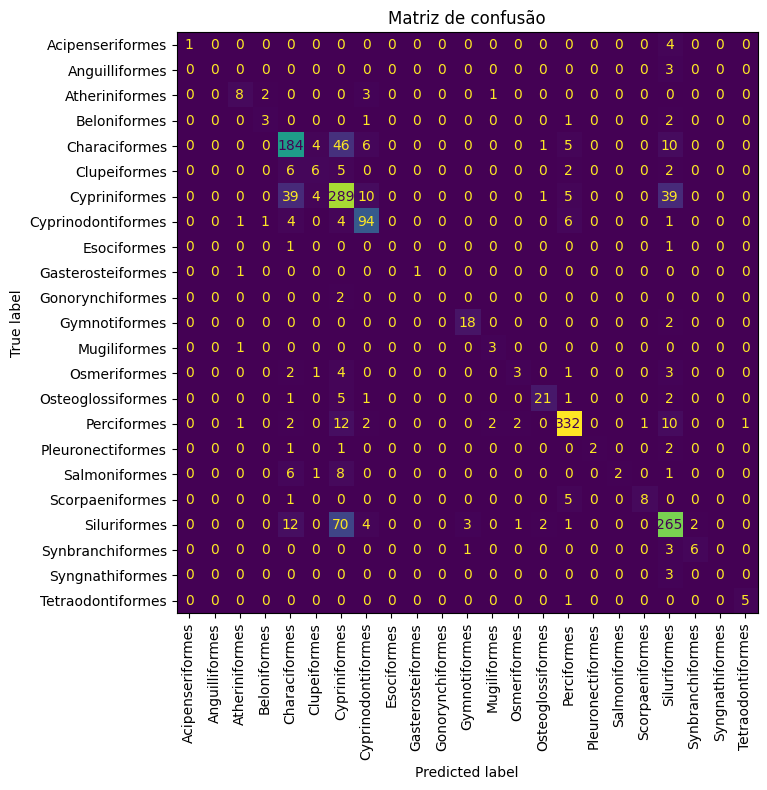

In [ ]:
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, xticks_rotation=90, colorbar=False)
ax.set_title("Matriz de confusão")
plt.tight_layout()
plt.show()
